In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import confusion_matrix, classification_report, f1_score

df = pd.read_csv(r"C:\\Users\\mailm\\Documents\\medilens-ai\\data\\diabetes_clean.csv")
X = df.drop(columns=["Outcome"])
y = df["Outcome"]
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,6.0,148.0,72.0,35.0,169.5,33.6,0.627,50.0,1.0
2,1.0,85.0,66.0,29.0,102.5,26.6,0.351,31.0,0.0
3,8.0,183.0,64.0,32.0,169.5,23.3,0.672,32.0,1.0
4,1.0,89.0,66.0,23.0,94.0,28.1,0.167,21.0,0.0


In [3]:
print("NaN in y (Outcome):", y.isnull().sum())
print("Total rows:", len(df))

NaN in y (Outcome): 1
Total rows: 769


In [4]:
df = df.dropna(subset=["Outcome"])

X = df.drop(columns=["Outcome"])
y = df["Outcome"]

print("Rows remaining:", len(df))
print("NaN in y:", y.isnull().sum())

Rows remaining: 768
NaN in y: 0


In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (614, 8)
Test size: (154, 8)


In [10]:
#Logistic Regression

print("=== Logistic Regression ===")
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_scaled, y_train)
y_pred_lr = log_reg.predict(X_test_scaled)

print(classification_report(y_test, y_pred_lr, target_names=["No Diabetes", "Diabetes"]))

=== Logistic Regression ===
              precision    recall  f1-score   support

 No Diabetes       0.77      0.79      0.78       100
    Diabetes       0.59      0.56      0.57        54

    accuracy                           0.71       154
   macro avg       0.68      0.67      0.67       154
weighted avg       0.70      0.71      0.71       154



In [8]:
#Random Forest

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("=== Random Forest ===")
print(classification_report(y_test, y_pred_rf, target_names=["No Diabetes", "Diabetes"]))

=== Random Forest ===
              precision    recall  f1-score   support

 No Diabetes       0.89      0.90      0.90       100
    Diabetes       0.81      0.80      0.80        54

    accuracy                           0.86       154
   macro avg       0.85      0.85      0.85       154
weighted avg       0.86      0.86      0.86       154



In [11]:
# XGBoost

xgb = XGBClassifier(random_state=42, eval_metric="logloss")
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)

print("=== XGBoost ===")
print(classification_report(y_test, y_pred_xgb, target_names=["No Diabetes", "Diabetes"]))

=== XGBoost ===
              precision    recall  f1-score   support

 No Diabetes       0.92      0.91      0.91       100
    Diabetes       0.84      0.85      0.84        54

    accuracy                           0.89       154
   macro avg       0.88      0.88      0.88       154
weighted avg       0.89      0.89      0.89       154



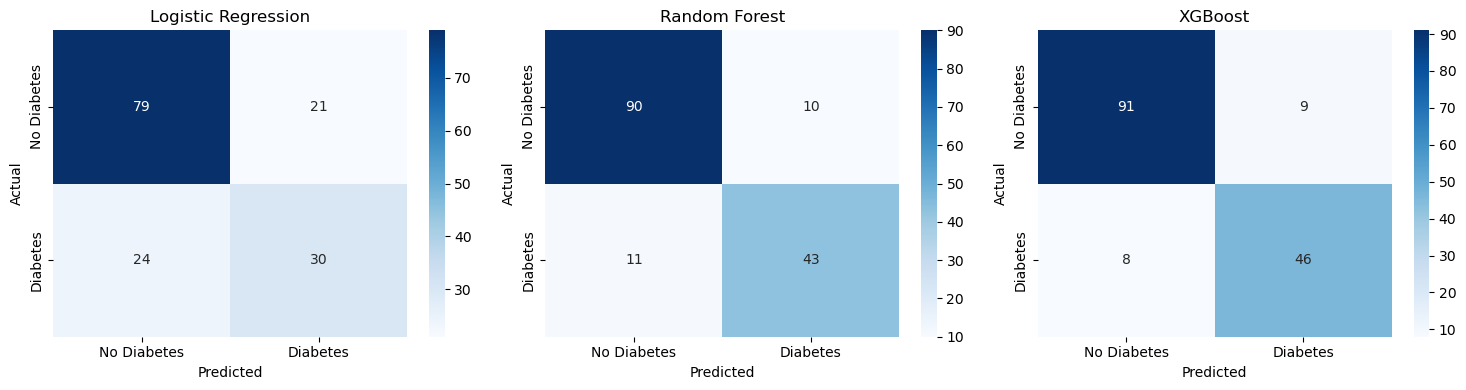

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

models = [
    ("Logistic Regression", y_pred_lr),
    ("Random Forest", y_pred_rf),
    ("XGBoost", y_pred_xgb)
]

for ax, (name, preds) in zip(axes, models):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["No Diabetes", "Diabetes"],
                yticklabels=["No Diabetes", "Diabetes"])
    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.show()

In [13]:
from sklearn.decomposition import PCA
import time

# Without PCA
t1 = time.time()
xgb_full = XGBClassifier(random_state=42, eval_metric="logloss")
xgb_full.fit(X_train, y_train)
t2 = time.time()
f1_full = f1_score(y_test, xgb_full.predict(X_test))

# With PCA (6 components)
pca = PCA(n_components=6)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

t3 = time.time()
xgb_pca = XGBClassifier(random_state=42, eval_metric="logloss")
xgb_pca.fit(X_train_pca, y_train)
t4 = time.time()
f1_pca = f1_score(y_test, xgb_pca.predict(X_test_pca))

print(f"Without PCA — F1: {f1_full:.3f} | Time: {t2-t1:.4f}s")
print(f"With PCA    — F1: {f1_pca:.3f} | Time: {t4-t3:.4f}s")
print(f"\nVariance explained by 6 components: {sum(pca.explained_variance_ratio_):.2%}")

Without PCA — F1: 0.844 | Time: 0.2218s
With PCA    — F1: 0.752 | Time: 0.2541s

Variance explained by 6 components: 89.95%


In [14]:
import joblib
import os

os.makedirs("../models", exist_ok=True)

joblib.dump(xgb, "../models/best_model.pkl")
joblib.dump(scaler, "../models/scaler.pkl")
joblib.dump(list(X.columns), "../models/feature_names.pkl")

print("Models saved successfully!")

Models saved successfully!


In [16]:
import os

data_path = "../data/chest_xray"
for split in ["train", "val", "test"]:
    for label in ["NORMAL", "PNEUMONIA"]:
        path = os.path.join(data_path, split, label)
        if os.path.exists(path):
            count = len(os.listdir(path))
            print(f"{split}/{label}: {count} images")
        else:
            print(f"NOT FOUND: {split}/{label}")

train/NORMAL: 1341 images
train/PNEUMONIA: 3875 images
val/NORMAL: 8 images
val/PNEUMONIA: 8 images
test/NORMAL: 234 images
test/PNEUMONIA: 390 images
